**Itens obrigatórios:**

1. [OK] Investigue os dados com estatísticas descritivas. 
2. [OK] Crie visualizações que trazem insights. 
3. [OK] Trate valores ausentes de forma adequada.
4. [OK] Criar variáveis derivadas (ex.: período do dia, feriados, estações do ano). 
5. [OK] Analisar atrasos por aeroporto, companhia ou estado. 
6. Criar mapas geográficos de rotas e atrasos.
7. Identificar padrões sazonais ou horários críticos.  
8. Modelagem supervisionada (mínimo um modelo)
    * Classificação: prever se um voo vai atrasar ou não. 
    OU
    * Regressão: prever quanto tempo o atraso vai durar. Compare pelo menos dois algoritmos diferentes e avalie com métricas adequadas.   
9. Modelagem não supervisionada (mínimo uma abordagem):
    * Use clusterização (ex.: agrupar rotas, aeroportos ou companhias aéreas) ou redução de dimensionalidade (ex.: PCA). 
    * Mostre os resultados em gráficos e faça a interpretação. 
    * Compartilhe as principais conclusões. 
    * Discuta as limitações dos modelos. 
    * Proponha melhorias e próximos passos

______________

### 1. Importações

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

### 2. Carregamento dos dados

#### 2.1 Carrega df_airlines


In [3]:
#Carrega df_airlines
df_airlines = pd.read_csv("../data/raw/airlines.csv")

#Visualiza df_airlines
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


#### 2.2 Carrega df_airports


In [4]:
#Carrega df_airports
df_airports = pd.read_csv("../data/raw/airports.csv")

#Visualiza df_airports
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


#### 2.3 Carrega df_flights

In [5]:
#Carrega df_flights
pd.set_option('display.max_columns', None) #visualizar todas as colunas
df_flights = pd.read_csv("../data/raw/flights.csv")

#Visualiza df_flights
df_flights.head()

C:\Users\alice\AppData\Local\Temp\ipykernel_3604\923866933.py:3: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv("../data/raw/flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


| Coluna              | Descrição                                                                | Tipo       |
| ------------------- | ------------------------------------------------------------------------ | ---------- |
| YEAR                | Ano do voo (ex.: 2015)                                                   | Inteiro    |
| MONTH               | Mês do voo (1 a 12)                                                      | Inteiro    |
| DAY                 | Dia do mês do voo (1 a 31)                                               | Inteiro    |
| DAY_OF_WEEK         | Dia da semana (1 = Segunda, 7 = Domingo)                                 | Inteiro    |
| AIRLINE             | Código da companhia aérea (ex.: AA = American Airlines)                  | Categórica |
| FLIGHT_NUMBER       | Número do voo                                                            | Inteiro    |
| TAIL_NUMBER         | Número de registro da aeronave                                           | Texto      |
| ORIGIN_AIRPORT      | Código IATA do aeroporto de origem (ex.: ATL)                            | Categórica |
| DESTINATION_AIRPORT | Código IATA do aeroporto de destino                                      | Categórica |
| SCHEDULED_DEPARTURE | Horário de partida programado (HHMM)                                     | Inteiro    |
| DEPARTURE_TIME      | Horário real de partida (HHMM)                                           | Inteiro    |
| DEPARTURE_DELAY     | Atraso na partida (em minutos)                                           | Numérico   |
| TAXI_OUT            | Tempo gasto taxiando até a decolagem (em minutos)                        | Numérico   |
| WHEELS_OFF          | Horário em que o avião decolou (HHMM)                                    | Inteiro    |
| SCHEDULED_TIME      | Tempo total programado de voo (em minutos)                               | Numérico   |
| ELAPSED_TIME        | Tempo total real de voo (em minutos)                                     | Numérico   |
| AIR_TIME            | Tempo no ar (em minutos)                                                 | Numérico   |
| DISTANCE            | Distância entre origem e destino (em milhas)                             | Numérico   |
| WHEELS_ON           | Horário em que as rodas tocaram o solo (HHMM)                            | Inteiro    |
| TAXI_IN             | Tempo taxiando até o portão de desembarque (em minutos)                  | Numérico   |
| SCHEDULED_ARRIVAL   | Horário de chegada programado (HHMM)                                     | Inteiro    |
| ARRIVAL_TIME        | Horário de chegada real (HHMM)                                           | Inteiro    |
| ARRIVAL_DELAY       | Atraso na chegada (em minutos)                                           | Numérico   |
| DIVERTED            | Indica se o voo foi desviado (1 = sim, 0 = não)                          | Binária    |
| CANCELLED           | Indica se o voo foi cancelado (1 = sim, 0 = não)                         | Binária    |
| CANCELLATION_REASON | Motivo do cancelamento (A = Airline, B = Weather, C = NAS, D = Security) | Categórica |
| AIR_SYSTEM_DELAY    | Atraso causado por controle de tráfego aéreo                             | Numérico   |
| SECURITY_DELAY      | Atraso causado por problemas de segurança                                | Numérico   |
| AIRLINE_DELAY       | Atraso causado pela companhia aérea                                      | Numérico   |
| LATE_AIRCRAFT_DELAY | Atraso causado por chegada tardia da aeronave                            | Numérico   |
| WEATHER_DELAY       | Atraso causado por condições meteorológicas                              | Numérico   |


#### 2.4 Base final com informações entre as três fontes origens cruzadas


In [6]:
#Cruza origens
df = pd.merge(df_flights, df_airports, left_on="ORIGIN_AIRPORT",right_on="IATA_CODE", how="left")
df = pd.merge(df, df_airlines, left_on="AIRLINE",right_on="IATA_CODE", how="left")

#apaga colunas duplicadas por conta do join e renomeia colunas 
df = df.drop(columns=["IATA_CODE_y","IATA_CODE_x"])
df = df.rename(columns={
    "AIRLINE_y": "AIRLINE_NAME",
    "AIRLINE_x": "AIRLINE_CODE"
})

#visualizar todas as colunas
pd.set_option('display.max_columns', None) 
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,AIRLINE_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Alaska Airlines Inc.


### 3. Preparação dos dados

#### 3.1 Filtro de voos com potencial de agregar informações de fato:

Removemos os voos cancelados ou desviados, porque não foram iniciados ou finalizados com sucesso, e por isso não fornecem informações úteis sobre o desempenho dos voos para identificarmos padrões de atraso. Além disso, o filtro ajuda a reduzir o tamanho da base de dados.

In [7]:
df_filtrado = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0)
]

#### 3.2 Tratamento de vazamento de informações:

Para evitar data leakage (usar informações que só existem depois do voo acontecer, que podem vazar informações sobre se houve atraso ou não), devemos remover as variaveis que não estariam disponíveis no momento em que queremos fazer a previsão, ou seja, antes do voo atrasar de fato.

Além disso, existem dados que não agregam informações. Estes também serão removidos.

In [8]:
remove_data_leakage = [
    "ARRIVAL_TIME", #só existe depois que o atraso já ocorreu
    "AIR_SYSTEM_DELAY", #motivo só existe depois que o atraso já ocorreu
    "SECURITY_DELAY", #motivo só existe depois que o atraso já ocorreu
    "AIRLINE_DELAY", #motivo só existe depois que o atraso já ocorreu
    "LATE_AIRCRAFT_DELAY", #motivo só existe depois que o atraso já ocorreu
    "WEATHER_DELAY", #motivo só existe depois que o atraso já ocorreu
    "CANCELLATION_REASON", #se o voo foi cancelado, não houve atraso 
    "WHEELS_ON", #indica que o voo já terminou e já se sabe seu tempo de duração - queremos prever o atraso com antecedência 
    "AIR_TIME", #para saber quanto tempo o avião ficou no ar, é necessário saber a hora do pouso e calcular a diferença (Se o modelo souber que o voo demorou muito no ar, ele já tem forte pista sobre o atraso)
    "ELAPSED_TIME", #o valor só é conhecido depois que o voo terminou
    "TAXI_IN", #só acontece no final do voo, então já se sabe o atraso final 
    "COUNTRY", #não varia, o único valor possível é 'USA', então não agrega informação
    "AIRLINE_NAME", #como já existe o AIRLINE_CODE, não precisa de duas variáveis com a mesma informação
    "CANCELLED", #filtramos na etapa anterior
    "DIVERTED", #filtramos na etapa anterior
    "DEPARTURE_TIME",
    "ARRIVAL_DELAY",
    "TAXI_OUT",
    "WHEELS_OFF"
]

df_reduzido = df_filtrado.drop(columns=remove_data_leakage)

### 3.3 Tratamento de valores faltantes 


Existem valores faltantes para as colunas AIRPORT, CITY, STATE, LATITUDE e LONGITUDE. Porque o match entre as origens não foi 100%.

In [8]:
# df_reduzido.isnull().sum()

YEAR                        0
MONTH                       0
DAY                         0
DAY_OF_WEEK                 0
AIRLINE_CODE                0
FLIGHT_NUMBER               0
TAIL_NUMBER                 0
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
SCHEDULED_DEPARTURE         0
DEPARTURE_DELAY             0
SCHEDULED_TIME              0
DISTANCE                    0
SCHEDULED_ARRIVAL           0
AIRPORT                482878
CITY                   482878
STATE                  482878
LATITUDE               487439
LONGITUDE              487439
dtype: int64

Note que a chave de cruzamento "ORIGIN_AIRPORT" da base df_flight possui valores numéricos e alfanuméricos:

In [9]:
#print("Quantidade de valores numéricos: ", df_reduzido["ORIGIN_AIRPORT"].str.isnumeric().sum())
#print("Quantidade de valores alfanuméricos: ", df_reduzido["ORIGIN_AIRPORT"].str.isalpha().sum())

Quantidade de valores numéricos:  26881
Quantidade de valores alfanuméricos:  5231130


Ao passo que a chave correspondente na base df_airports não há valores numéricos: 

In [10]:
#print("Quantidade de valores numéricos: ", df_airports["IATA_CODE"].str.isnumeric().sum())
#print("Quantidade de valores alfanuméricos: ", df_airports["IATA_CODE"].str.isalpha().sum())

Quantidade de valores numéricos:  0
Quantidade de valores alfanuméricos:  322


In [11]:
#print("Existem ", df_reduzido["CITY"].isnull().sum(), "registros com valores regionais sobre o aeroporto faltando.")
#print("Considernado um total de",df_reduzido.shape[0], "registros até o momento," )
#
#a = df_reduzido["CITY"].isnull().sum()
#b = df_reduzido.shape[0]
#
#print("removê-los ainda irá manter", round((1-(a/b)),3)*100 , "% do volume de dados.")

Existem  482878 registros com valores regionais sobre o aeroporto faltando.
Considernado um total de 5714008 registros até o momento,
removê-los ainda irá manter 91.5 % do volume de dados.


In [9]:
df_reduzido = df_reduzido.dropna(
    subset=["AIRPORT","CITY","STATE","LATITUDE","LONGITUDE"]
)

In [13]:
#print("O tamanho do dataset original era de", df.shape[0], "registros.")
#print("O tamanho do dataset após a limpeza tornou-se de", df_reduzido.shape[0], "registros.")
#print("Mantemos ", round(df_reduzido.shape[0]/df.shape[0],3)*100, "% dos dados originais.")

O tamanho do dataset original era de 5819079 registros.
O tamanho do dataset após a limpeza tornou-se de 5226569 registros.
Mantemos  89.8 % dos dados originais.


#### 3.4 Engenharia de feature: criação de novas colunas

In [10]:
df_enriquecido = df_reduzido

3.4.1 Criação da coluna "period_of_day"


In [11]:
df_enriquecido["HOUR_SCHEDULED_DEPARTURE"] = (df_enriquecido["SCHEDULED_DEPARTURE"] // 100).astype(int)

morning_hours = set(range(0, 12))
afternoon_hours = set(range(12, 18))
night_hours = set(range(18, 24))

#cria colunas
df_enriquecido["IS_MORNING"] = df_enriquecido["HOUR_SCHEDULED_DEPARTURE"].isin(morning_hours).astype(int)
df_enriquecido["IS_AFTERNOON"] = df_enriquecido["HOUR_SCHEDULED_DEPARTURE"].isin(afternoon_hours).astype(int)
df_enriquecido["IS_NIGHT"] = df_enriquecido["HOUR_SCHEDULED_DEPARTURE"].isin(night_hours).astype(int)

3.4.2 Criaçao da coluna "holiday"

In [12]:
us_holidays = holidays.US(years=2015)
holiday_dates = pd.to_datetime(list(us_holidays.keys()))
print(holiday_dates)

DatetimeIndex(['2015-01-01', '2015-05-25', '2015-07-04', '2015-07-03',
               '2015-09-07', '2015-11-26', '2015-12-25', '2015-01-19',
               '2015-02-16', '2015-10-12', '2015-11-11'],
              dtype='datetime64[s]', freq=None)


In [13]:
df_enriquecido["DATE"] = pd.to_datetime(df_enriquecido[["YEAR","MONTH","DAY"]])
df_enriquecido["IS_HOLIDAY"] = df_enriquecido["DATE"].isin(holiday_dates).astype(int)

3.4.3 Criação da coluna "season"

In [14]:
# Inverno: 21 Dez → 19 Mar
winter_dates = set(pd.date_range("2015-01-01", "2015-03-19")) | \
               set(pd.date_range("2015-12-21", "2015-12-31"))

# Primavera: 20 Mar → 20 Jun
spring_dates = set(pd.date_range("2015-03-20", "2015-06-20"))

# Verão: 21 Jun → 22 Set
summer_dates = set(pd.date_range("2015-06-21", "2015-09-22"))

# Outono: 23 Set → 20 Dez
fall_dates = set(pd.date_range("2015-09-23", "2015-12-20"))


#Cria colunas
df_enriquecido["IS_WINTER"] = df_enriquecido["DATE"].isin(winter_dates).astype(int)
df_enriquecido["IS_SPRING"] = df_enriquecido["DATE"].isin(spring_dates).astype(int)
df_enriquecido["IS_SUMMER"] = df_enriquecido["DATE"].isin(summer_dates).astype(int)
df_enriquecido["IS_FALL"] = df_enriquecido["DATE"].isin(fall_dates).astype(int)

3.4.4 Cria categoria para distancia

In [15]:
# curta: < 500
short_distance = set(range(0, 500))

# média: 500 - 1499
medium_distance = set(range(500, 1500))

# longa: >= 1500
long_distance = set(range(1500, int(df_enriquecido["DISTANCE"].max()) + 1))

#Cria colunas 
df_enriquecido["IS_SHORT_DISTANCE"] = df_enriquecido["DISTANCE"].isin(short_distance).astype(int)
df_enriquecido["IS_MEDIUM_DISTANCE"] = df_enriquecido["DISTANCE"].isin(medium_distance).astype(int)
df_enriquecido["IS_LONG_DISTANCE"] = df_enriquecido["DISTANCE"].isin(long_distance).astype(int)

3.4.5 Cria flag de atraso, e normalmente usa-se o critério da aviação (Bureau of Transportation Statistics):
* Atraso ≥ 15 minutos → voo atrasado
* Atraso < 15 minutos → no horário

In [16]:
df_enriquecido["IS_DELAYED"] = (df_enriquecido["DEPARTURE_DELAY"] >= 15).astype(int)

### 4. Análise exploratória

1. Voos de algum período (manha/tarde/noite) atrasam mais?
2. Atraso na partida está diretamente ligado com atraso na chegada?
3. Voos mais longos atrasam mais?
4. Companhias aéreas específicas atrasam mais?
5. Existe uma rota que atrasa mais?
6. Existe um aeroporto que atras mais?
7. Existe sazonalidade? 
8. Os dados estão balanceados? ou existe mais registro de aeroportos/regioes específicas?
9. Quais aeroportos são mais críticos em relação a atrasos? 
10. Que características aumentam a chance de atraso em um voo? 
11. Os atrasos são mais comuns em certos dias da semana ou horários? 
12. É possível agrupar aeroportos com perfis semelhantes? 
13. Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?


In [20]:
df_exploratoria = df_enriquecido

A base ficou com essa estrutura após a engenharia de feature e tratamentos:

In [21]:
df_exploratoria.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIRPORT,CITY,STATE,LATITUDE,LONGITUDE,HOUR_SCHEDULED_DEPARTURE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,DATE,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,-11.0,205.0,1448,430,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,0,1,0,0,2015-01-01,1,1,0,0,0,0,1,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,-8.0,280.0,2330,750,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,0,1,0,0,2015-01-01,1,1,0,0,0,0,0,1
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,-2.0,286.0,2296,806,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,0,1,0,0,2015-01-01,1,1,0,0,0,0,0,1
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,-5.0,285.0,2342,805,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,0,1,0,0,2015-01-01,1,1,0,0,0,0,0,1
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,-1.0,235.0,1448,320,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,0,1,0,0,2015-01-01,1,1,0,0,0,0,1,0


3.4.1 Estrutura dos dados

O dataset tem cerca de 5,7 milhões de voos.

In [22]:
df_exploratoria.shape

(5226569, 32)

In [23]:
df_exploratoria[["SCHEDULED_DEPARTURE", "SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "DEPARTURE_DELAY"]].describe()

,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DEPARTURE_DELAY
count,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06
mean,1.329546e+03,1.420431e+02,8.254414e+02,1.493205e+03,9.699214e+00
std,4.840856e+02,7.537698e+01,6.088503e+02,5.077077e+02,3.739250e+01
min,1.000000e+00,1.800000e+01,3.100000e+01,1.000000e+00,-8.200000e+01
25%,9.160000e+02,8.600000e+01,3.730000e+02,1.110000e+03,-5.000000e+00
50%,1.325000e+03,1.230000e+02,6.510000e+02,1.520000e+03,-1.000000e+00
75%,1.730000e+03,1.740000e+02,1.067000e+03,1.918000e+03,8.000000e+00
max,2.359000e+03,7.180000e+02,4.983000e+03,2.400000e+03,1.988000e+03


3.4.2 Os dados estao balanceados?

In [28]:
df_exploratoria['DAY_OF_WEEK'].value_counts()

In [ ]:
df_exploratoria['AIRLINE_CODE'].value_counts()

In [ ]:
df_exploratoria['STATE'].value_counts()

In [ ]:
df_exploratoria['AIRLINE_CODE'].value_counts()

Visualizações

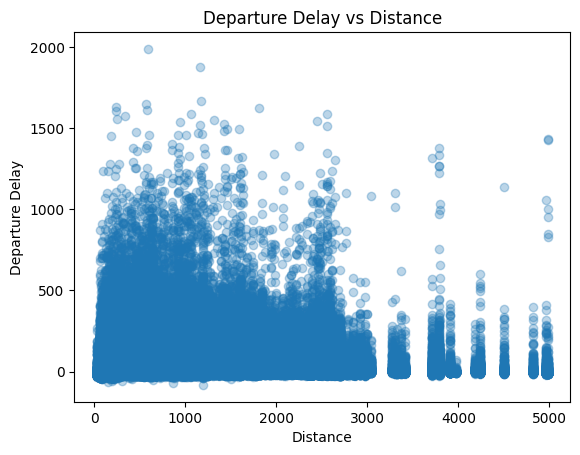

In [24]:
plt.figure()
plt.scatter(df_exploratoria["DISTANCE"], df_exploratoria["DEPARTURE_DELAY"], alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Departure Delay")
plt.title("Departure Delay vs Distance")
plt.show()

In [25]:
# Selecionar as variáveis numéricas que você mencionou + target
cols = ["SCHEDULED_DEPARTURE", "SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "DEPARTURE_DELAY"]

# Criar um dataframe apenas com essas colunas
df_corr = df_exploratoria[cols]

corr_matrix = df_corr.corr()

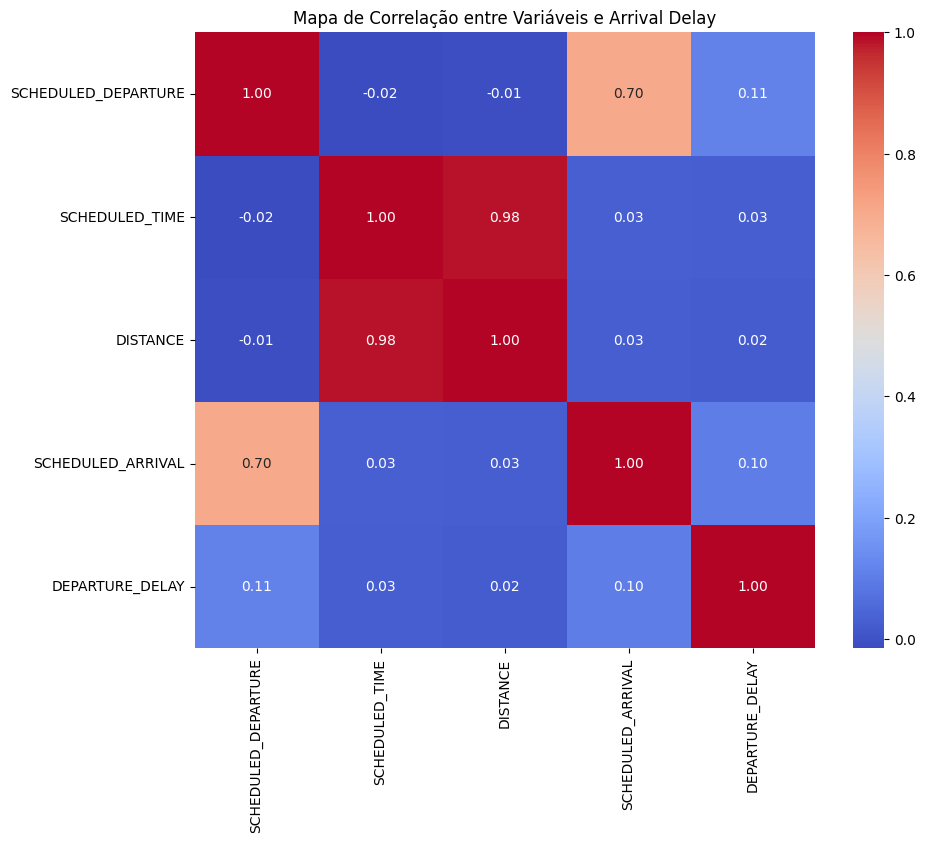

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de Correlação entre Variáveis e Arrival Delay")
plt.show()